### 02. Exploratory Data Analysis - Automobile Loan Default Prediction
 

#### 1. Setup




In [1]:
#import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)
sns.set_style('whitegrid')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Relative path handling: works whether launched from the workspace root or inside the notebooks folder
data_path = 'data/raw/Train_Dataset.csv' if os.path.exists('data/raw/Train_Dataset.csv') else '../data/raw/Train_Dataset.csv'

df = pd.read_csv(data_path, low_memory=False)

print(f"Dataset loaded successfully from: '{data_path}'")
print(f"Shape: {df.shape}")

Dataset loaded successfully from: '../data/raw/Train_Dataset.csv'
Shape: (121856, 40)


In [3]:
# Columns identified in 01_data_understanding.ipynb as numeric-looking but stored as text
# because of stray non-numeric characters ('$', 'x', '&', '#VALUE!', '@', '#')
candidate_numerical_cols = [
    'Client_Income',
    'Credit_Amount',
    'Loan_Annuity',
    'Population_Region_Relative',
    'Age_Days',
    'Employed_Days',
    'Registration_Days',
    'ID_Days',
    'Score_Source_3'
]

# Work on a copy so the raw df stays untouched
eda_df = df.copy()

extra_nans_introduced = {}
for col in candidate_numerical_cols:
    before_missing = eda_df[col].isna().sum()
    eda_df[col] = pd.to_numeric(eda_df[col], errors='coerce')
    after_missing = eda_df[col].isna().sum()
    extra_nans_introduced[col] = after_missing - before_missing

print("Extra NaNs introduced per column by coercing invalid text to NaN:")
for col, n in extra_nans_introduced.items():
    print(f"  {col:30s}: {n}")

print(f"\neda_df dtypes for these columns are now:")
print(eda_df[candidate_numerical_cols].dtypes)

Extra NaNs introduced per column by coercing invalid text to NaN:
  Client_Income                 : 15
  Credit_Amount                 : 5
  Loan_Annuity                  : 14
  Population_Region_Relative    : 11
  Age_Days                      : 17
  Employed_Days                 : 17
  Registration_Days             : 17
  ID_Days                       : 17
  Score_Source_3                : 1

eda_df dtypes for these columns are now:
Client_Income                 float64
Credit_Amount                 float64
Loan_Annuity                  float64
Population_Region_Relative    float64
Age_Days                      float64
Employed_Days                 float64
Registration_Days             float64
ID_Days                       float64
Score_Source_3                float64
dtype: object


**What this confirms:** the number of extra `NaN`s introduced per column should match the "Corrupted_Rows_Count" reported for each column in `01_data_understanding.ipynb` — this is the same set of dirty rows, just now converted to missing rather than left as text. All nine columns are now `float64`, so they can be plotted and summarised numerically for the rest of this notebook.


### 2. Descriptive Statistics

Before jumping into visualisations, we get a numeric summary of every column. This is the fastest way to catch implausible values (e.g. an "age in days" that doesn't correspond to any real age, or a score outside its expected 0–1 range) — this is exactly how the `Employed_Days` sentinel value mentioned in our dataset proposal should reveal itself, via an unrealistic **max**.

- `describe()` on numeric columns gives count, mean, std, min, 25/50/75th percentiles, and max.
- `describe(include='object')` on categorical columns gives count, number of unique values, the most frequent category, and its frequency — useful for spotting a placeholder category (like a disguised `"XNA"` missing value) hiding behind a real-looking category name.


In [4]:
numeric_summary = eda_df.select_dtypes(include=[np.number]).describe().T
numeric_summary

,count,mean,std,min,25%,50%,75%,max
ID,121856.0,1.216093e+07,35176.941538,1.210000e+07,1.213046e+07,1.216093e+07,1.219139e+07,1.222186e+07
Client_Income,118234.0,1.686519e+04,11538.154494,2.565000e+03,1.125000e+04,1.440000e+04,2.025000e+04,1.800009e+06
Car_Owned,118275.0,3.428535e-01,0.474665,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
Bike_Owned,118232.0,3.322620e-01,0.471026,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
Active_Loan,118221.0,4.991753e-01,0.500001,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
House_Own,118195.0,6.920597e-01,0.461644,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
Child_Count,118218.0,4.177790e-01,0.728802,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.900000e+01
Credit_Amount,118219.0,6.004649e+04,40350.663346,4.500000e+03,2.700000e+04,5.175000e+04,8.086500e+04,4.050000e+05
Loan_Annuity,117030.0,2.721254e+03,1461.466162,2.173500e+02,1.657350e+03,2.499750e+03,3.466800e+03,2.250000e+04
Population_Region_Relative,116988.0,2.260243e-02,0.413617,5.330000e-04,1.000600e-02,1.885000e-02,2.866300e-02,1.000000e+02


**Interpretation:** watch the `max` column for `Employed_Days` in particular — the dataset proposal flagged `365243` as a known placeholder for applicants who are not currently employed. If it stands out here, we investigate it properly in Section 3.


In [5]:
categorical_summary = eda_df.select_dtypes(include=['object']).describe().T
categorical_summary

C:\Users\amami\AppData\Local\Temp\ipykernel_13744\1210182893.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_summary = eda_df.select_dtypes(include=['object']).describe().T


,count,unique,top,freq
Accompany_Client,120110,7,Alone,97409
Client_Income_Type,118155,8,Service,61028
Client_Education,118211,5,Secondary,83911
Client_Marital_Status,118383,4,M,87349
Client_Gender,119443,3,Male,78463
Loan_Contract_Type,118205,2,CL,107118
Client_Housing_Type,118169,6,Home,104870
Client_Occupation,80421,18,Laborers,21024
Client_Permanent_Match_Tag,121856,2,Yes,112454
Client_Contact_Work_Tag,121856,2,Yes,100015


**Interpretation:** for each categorical column, compare `unique` against what you'd expect for that field, and check whether `top` (the most frequent value) looks like a genuine category or a placeholder (e.g. `"XNA"`). We'll dig into this properly in Section 4.


## 3. Sentinel Value Investigation: `Employed_Days` = 365243

Section 2 confirmed `Employed_Days` has a `max` of exactly `365243` — the placeholder value flagged in our dataset proposal. `365243` days is roughly 1,000 years, which is not a genuine employment duration, so this must be a code used by the data source rather than a real measurement.

We now quantify how many rows are affected and check whether it lines up with applicants who would plausibly have no current employment (e.g. retired or unemployed), to confirm our hypothesis before deciding how to treat it in `03_data_preprocessing.ipynb`.


In [6]:
sentinel_value = 365243
is_sentinel = eda_df['Employed_Days'] == sentinel_value

sentinel_count = is_sentinel.sum()
sentinel_pct = is_sentinel.mean() * 100

print(f"Rows with Employed_Days == {sentinel_value}: {sentinel_count:,} ({sentinel_pct:.2f}% of all records)")

Rows with Employed_Days == 365243: 21,098 (17.31% of all records)


**Interpretation:** this is not a handful of stray rows — it affects a substantial share of the dataset, so it cannot simply be dropped as a rare data-entry mistake. It needs a deliberate, explicit handling strategy.


In [7]:
# Compare Client_Income_Type distribution for sentinel vs non-sentinel applicants
income_type_sentinel = eda_df.loc[is_sentinel, 'Client_Income_Type'].value_counts(normalize=True).mul(100).round(2)
income_type_non_sentinel = eda_df.loc[~is_sentinel, 'Client_Income_Type'].value_counts(normalize=True).mul(100).round(2)

comparison = pd.DataFrame({
    'Sentinel_Rows_%': income_type_sentinel,
    'Non_Sentinel_Rows_%': income_type_non_sentinel
}).fillna(0)

comparison

,Sentinel_Rows_%,Non_Sentinel_Rows_%
Client_Income_Type,,
Businessman,0.00,0.00
Commercial,0.00,28.41
Govt Job,0.00,8.49
Maternity leave,0.00,0.00
Retired,99.98,0.65
Service,0.00,62.44
Student,0.00,0.01
Unemployed,0.02,0.00


**Interpretation:** among rows where `Employed_Days` is the sentinel value, **99.98% are `Retired`** (the remaining 0.02% are `Unemployed`). Among all other rows, `Retired` barely appears (0.65% — this small share includes rows where `Employed_Days` is itself missing, not just genuinely-employed retirees) — the working population is split across `Service`, `Commercial`, and `Government` income types instead. This confirms the hypothesis from the dataset proposal: `365243` is a system placeholder meaning "not currently employed," used almost exclusively for retired applicants.


In [8]:
# Compare the Default rate between sentinel and non-sentinel applicants
default_rate_sentinel = eda_df.loc[is_sentinel, 'Default'].mean() * 100
default_rate_non_sentinel = eda_df.loc[~is_sentinel, 'Default'].mean() * 100

print(f"Default rate WHEN Employed_Days is the sentinel (365243): {default_rate_sentinel:.2f}%")
print(f"Default rate WHEN Employed_Days is a real value:          {default_rate_non_sentinel:.2f}%")

Default rate WHEN Employed_Days is the sentinel (365243): 5.53%
Default rate WHEN Employed_Days is a real value:          8.61%


**Interpretation:** the sentinel group (mostly retirees) defaults *less* often (≈5.5%) than applicants with a genuine employment duration (≈8.7%). This is a meaningful signal, not noise — which is exactly why we shouldn't just impute `365243` away as a missing value or leave it as a raw number (its huge magnitude would otherwise distort any model that uses `Employed_Days` as a plain numeric feature, e.g. by dragging up the mean/variance or acting as an extreme outlier in distance-based models).

**Decision for `03_data_preprocessing.ipynb`:** convert `Employed_Days` into two features —
1. A binary flag (e.g. `Is_Retired_Or_Unemployed`) marking whether the row was `365243`.
2. The numeric `Employed_Days` value, with the sentinel rows set to a proper missing value (`NaN`) or `0`, so it no longer distorts scaling/statistics for applicants who are genuinely employed.

This lets the model use both pieces of information — the flag captures the meaningful "retired/unemployed" signal we just found, and the cleaned numeric column stays usable for applicants who do have real employment duration.


## 4. Disguised Missing Values in Categorical Columns

A `.isnull()` check only catches values that are *actually* stored as `NaN`. It won't catch a column where "missing" was instead encoded as a real-looking string, such as `"XNA"`. These disguised missing values are dangerous because they silently get treated as a genuine category (e.g. by one-hot encoding) unless we deliberately look for them.

We scan every genuine categorical column (the 11 columns confirmed in Section 2's `categorical_summary`) for a set of common placeholder tokens.


In [9]:
placeholder_tokens = ['XNA', 'Unknown', 'unknown', 'N/A', 'NA', 'na', 'None', 'none', '-', '?', 'Not specified', 'Not Specified']

categorical_cols = eda_df.select_dtypes(include='object').columns.tolist()

print(f"Scanning {len(categorical_cols)} categorical columns: {categorical_cols}\n")

placeholder_hits = {}
for col in categorical_cols:
    found = [v for v in eda_df[col].dropna().unique() if str(v).strip() in placeholder_tokens]
    if found:
        count = eda_df[col].isin(found).sum()
        placeholder_hits[col] = (found, count)

for col, (found, count) in placeholder_hits.items():
    pct = count / len(eda_df) * 100
    print(f"{col:25s}: found {found} in {count:,} rows ({pct:.2f}%)")

Scanning 11 categorical columns: ['Accompany_Client', 'Client_Income_Type', 'Client_Education', 'Client_Marital_Status', 'Client_Gender', 'Loan_Contract_Type', 'Client_Housing_Type', 'Client_Occupation', 'Client_Permanent_Match_Tag', 'Client_Contact_Work_Tag', 'Type_Organization']

Client_Gender            : found ['XNA'] in 3 rows (0.00%)
Type_Organization        : found ['XNA'] in 21,085 rows (17.30%)


C:\Users\amami\AppData\Local\Temp\ipykernel_13744\1413116448.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = eda_df.select_dtypes(include='object').columns.tolist()


**Interpretation:** this fixed-token scan catches two columns:
- `Client_Gender` has `"XNA"` in just **3 rows** — a negligible, isolated data-entry issue.
- `Type_Organization` has `"XNA"` in **21,085 rows (17.30%)** — far too large to be a random data-entry mistake, and suspiciously close to the 21,098-row `Employed_Days` sentinel count from Section 3. We investigate that connection next.

*(Note: a fixed token list can only catch placeholders we already thought to search for. Section 6's bar charts later surface a third one, `"##"` in `Accompany_Client`, that this list missed — handled below.)*


In [10]:
# Check whether Type_Organization == "XNA" is the same population as the Employed_Days sentinel
is_xna_org = eda_df['Type_Organization'] == 'XNA'

overlap = (is_sentinel & is_xna_org).sum()
xna_only = (is_xna_org & ~is_sentinel).sum()
sentinel_only = (is_sentinel & ~is_xna_org).sum()

print(f"Rows with BOTH Employed_Days sentinel AND Type_Organization == 'XNA': {overlap:,}")
print(f"Rows with Type_Organization == 'XNA' but a real Employed_Days value:   {xna_only:,}")
print(f"Rows with Employed_Days sentinel but a real Type_Organization:        {sentinel_only:,}")

Rows with BOTH Employed_Days sentinel AND Type_Organization == 'XNA': 20,454
Rows with Type_Organization == 'XNA' but a real Employed_Days value:   631
Rows with Employed_Days sentinel but a real Type_Organization:        644


**Interpretation:** the two match almost completely — 20,454 of the ~21,000 flagged rows overlap. This confirms `"XNA"` in `Type_Organization` is not random corruption; it means "not applicable" for applicants who have no current employer, i.e. the same retired/unemployed population identified in Section 3. It is a legitimate category, not something to impute with the most frequent organization type.


In [11]:
# Confirm the same lower-risk pattern holds for this column too
default_rate_xna = eda_df.loc[is_xna_org, 'Default'].mean() * 100
default_rate_non_xna = eda_df.loc[~is_xna_org, 'Default'].mean() * 100

print(f"Default rate WHEN Type_Organization == 'XNA': {default_rate_xna:.2f}%")
print(f"Default rate WHEN Type_Organization is a real org type: {default_rate_non_xna:.2f}%")

Default rate WHEN Type_Organization == 'XNA': 5.55%
Default rate WHEN Type_Organization is a real org type: 8.61%


In [12]:
# The 3 Client_Gender == 'XNA' rows, inspected individually
eda_df.loc[eda_df['Client_Gender'] == 'XNA', ['Client_Gender', 'Client_Income_Type', 'Default']]

,Client_Gender,Client_Income_Type,Default
17034,XNA,Service,0
30820,XNA,Service,0
68760,XNA,Commercial,0


**Interpretation:** the 3 `Client_Gender == "XNA"` rows are unrelated to the retirement pattern (they're `Service`/`Commercial` income types) — this looks like an isolated data-entry issue affecting only 3 out of 121,856 rows.

**Decisions for `03_data_preprocessing.ipynb`:**
1. `Type_Organization == "XNA"` will be **kept as its own valid category** (not imputed away), since it carries real information tied to the retirement/unemployment flag created in Section 3.
2. `Client_Gender == "XNA"` (3 rows) will be treated as **missing** and handled with the rest of `Client_Gender`'s missing values — the volume is too small to justify a special category.


## 5. Outlier and Unusual Observation Analysis

This section covers two things:
1. Resolving the two anomalies deferred from Section 2 (`Score_Source_2` and `Population_Region_Relative`, both showing an impossible `max` of 100).
2. A systematic outlier scan (IQR method) across the key numeric fields, with boxplots, to see how much of the data sits far outside the typical range for each.


### 5.1 `Score_Source_2` anomaly (max = 100)

`Score_Source_1` and `Score_Source_3` both range 0–1, consistent with typical normalised credit bureau scores. `Score_Source_2` should behave the same way, so any value of 100 is not a genuine score.


In [13]:
score2_anomaly = eda_df['Score_Source_2'] > 1
print(f"Rows with Score_Source_2 > 1: {score2_anomaly.sum()}")
eda_df.loc[score2_anomaly, ['Score_Source_1', 'Score_Source_2', 'Score_Source_3', 'Default']]

Rows with Score_Source_2 > 1: 6


,Score_Source_1,Score_Source_2,Score_Source_3,Default
44468,0.328688,100.0,0.403142,0
73097,0.638541,100.0,0.047601,0
105522,0.703553,100.0,0.535276,0
109378,NaN,100.0,0.164414,1
114099,NaN,100.0,0.683269,0
119243,0.465062,100.0,0.833787,0


**Interpretation:** only **6 rows** (0.005% of the data) show `Score_Source_2 == 100.0` exactly. This is far too small and too suspiciously round a number to be a real score — it looks like a data export artifact (e.g. a value meant to be a percentage, or a fixed error code) rather than genuine information. `Score_Source_1`/`Score_Source_3` for these same rows look perfectly normal, reinforcing that only this one field is corrupted for these 6 applicants.

**Decision:** treat these 6 values as missing (`NaN`) rather than as real scores.


### 5.2 `Population_Region_Relative` anomaly (max = 100)

The 25th/50th/75th percentiles for this column are all tiny fractions (roughly 0.0001–0.03), so a value of 100 is off by several orders of magnitude.


In [14]:
prr_anomaly = eda_df['Population_Region_Relative'] > 1
print(f"Rows with Population_Region_Relative > 1: {prr_anomaly.sum()}")
eda_df.loc[prr_anomaly, ['Population_Region_Relative', 'Default']]

Rows with Population_Region_Relative > 1: 2


,Population_Region_Relative,Default
33053,100.0,0
52949,100.0,0


**Interpretation:** just **2 rows** show this value, again exactly `100.0`. Same conclusion as `Score_Source_2` — an isolated corrupted value, not a genuine measurement.

**Decision:** treat these 2 values as missing (`NaN`) as well.


In [15]:
# Apply both fixes to eda_df so the rest of this notebook's plots/statistics
# aren't distorted by these 8 corrupted values (this mirrors the decision that will
# be implemented properly, on the training split only, in 03_data_preprocessing.ipynb)
eda_df.loc[eda_df['Score_Source_2'] > 1, 'Score_Source_2'] = np.nan
eda_df.loc[eda_df['Population_Region_Relative'] > 1, 'Population_Region_Relative'] = np.nan

print("Score_Source_2 new max:", eda_df['Score_Source_2'].max())
print("Population_Region_Relative new max:", eda_df['Population_Region_Relative'].max())

Score_Source_2 new max: 0.854999666
Population_Region_Relative new max: 0.072508


### 5.3 Systematic outlier scan (IQR method)

For the remaining key numeric fields, we use the standard IQR rule: any value below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR` is flagged as a statistical outlier. This does **not** mean every flagged value is an error — for skewed financial data (income, credit amount) a large share of "outliers" can simply be genuine high-value applicants. The goal here is to measure how much of the data is affected, then judge case by case using the boxplots.


In [16]:
key_numeric_cols = [
    'Client_Income', 'Credit_Amount', 'Loan_Annuity', 'Age_Days',
    'Score_Source_1', 'Score_Source_3', 'Social_Circle_Default', 'Credit_Bureau'
]

outlier_summary = []
for col in key_numeric_cols:
    s = eda_df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((s < lower) | (s > upper)).sum()
    outlier_summary.append({
        'Feature': col,
        'Q1': round(q1, 3),
        'Q3': round(q3, 3),
        'Lower_Bound': round(lower, 3),
        'Upper_Bound': round(upper, 3),
        'Outlier_Count': n_outliers,
        'Outlier_%': round(n_outliers / len(s) * 100, 2)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,Feature,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_%
0,Client_Income,11250.000,20250.000,-2250.000,33750.000,5392,4.56
1,Credit_Amount,27000.000,80865.000,-53797.500,161662.500,2567,2.17
2,Loan_Annuity,1657.350,3466.800,-1056.825,6180.975,2894,2.47
3,Age_Days,12398.000,19661.000,1503.500,30555.500,0,0.00
4,Score_Source_1,0.333,0.674,-0.177,1.185,0,0.00
5,Score_Source_3,0.372,0.667,-0.070,1.110,0,0.00
6,Social_Circle_Default,0.058,0.148,-0.078,0.285,4153,6.93
7,Credit_Bureau,0.000,3.000,-4.500,7.500,1303,1.26


**Interpretation:**
- `Client_Income` (4.56%), `Credit_Amount` (2.17%), and `Loan_Annuity` (2.47%) show moderate outlier rates — expected for right-skewed financial data. These are very likely genuine high-income/high-credit applicants rather than errors; we'll confirm visually below.
- `Age_Days` (0%) and both clean credit scores `Score_Source_1`/`Score_Source_3` (0%) show no IQR outliers at all — well-behaved variables.
- `Social_Circle_Default` (6.93%) and `Credit_Bureau` (1.26%) show more outliers, consistent with these being sparse, mostly-zero, count-like variables where a long right tail is expected rather than erroneous.

**Decision:** none of these will be removed as invalid data. Financial variables (`Client_Income`, `Credit_Amount`, `Loan_Annuity`) are candidates for a log-transform or capping in `03_data_preprocessing.ipynb` to reduce skew for models sensitive to scale; tree-based models (Random Forest, XGBoost) are unaffected by this skew regardless.


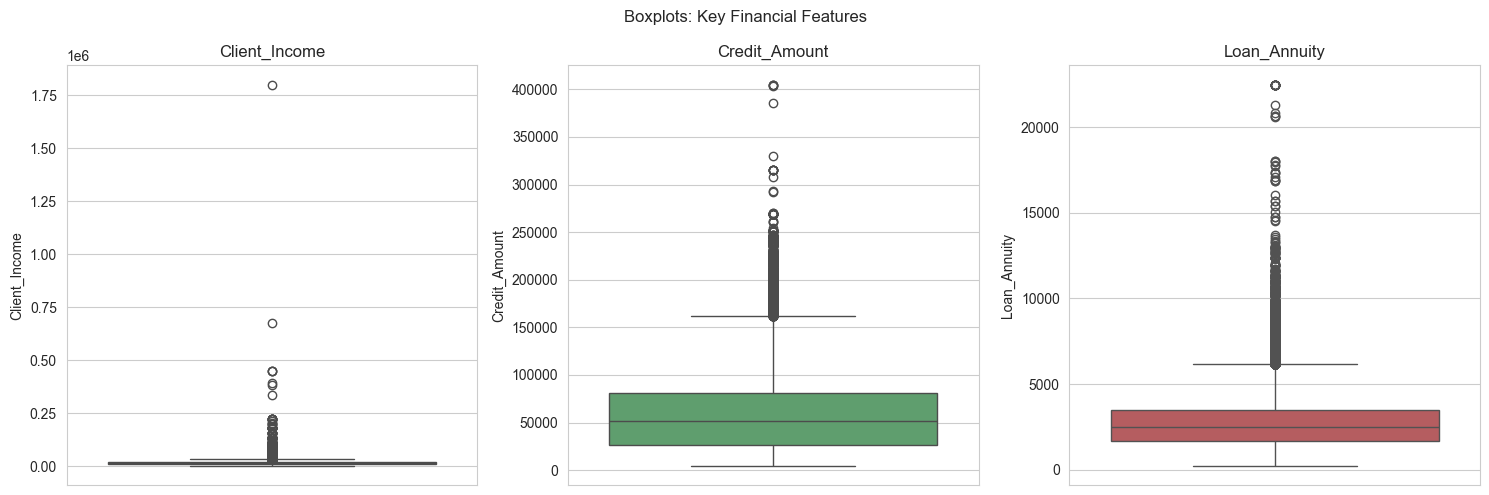

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=eda_df['Client_Income'], ax=axes[0], color='#4C72B0')
axes[0].set_title('Client_Income')

sns.boxplot(y=eda_df['Credit_Amount'], ax=axes[1], color='#55A868')
axes[1].set_title('Credit_Amount')

sns.boxplot(y=eda_df['Loan_Annuity'], ax=axes[2], color='#C44E52')
axes[2].set_title('Loan_Annuity')

fig.suptitle('Boxplots: Key Financial Features')
plt.tight_layout()

fig_dir = 'experiments/figures' if os.path.exists('experiments/figures') else '../experiments/figures'
plt.savefig(os.path.join(fig_dir, '05_financial_features_boxplots.png'), dpi=150)
plt.show()

**Interpretation:** all three distributions are right-skewed with a long tail of high-value applicants — the classic shape for income/credit/loan-size data. The boxes (25th–75th percentile) are tight and low relative to the whisker length, confirming most applicants cluster around modest values while a smaller group of higher earners/higher-credit applicants stretches the range. Nothing here looks like a data error.


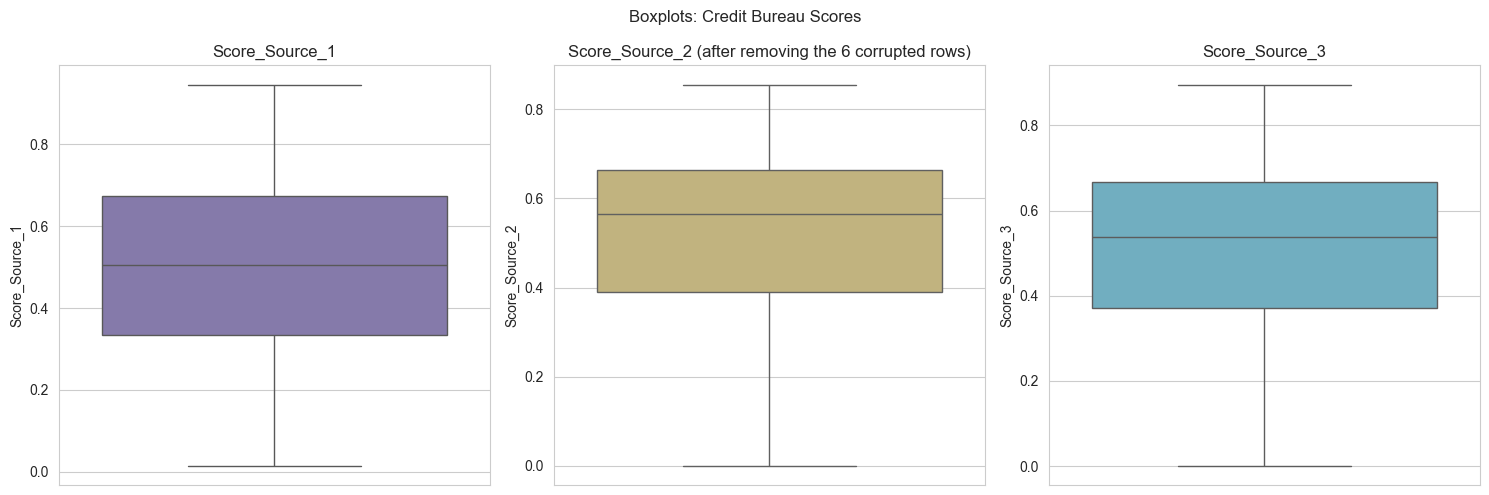

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=eda_df['Score_Source_1'], ax=axes[0], color='#8172B2')
axes[0].set_title('Score_Source_1')

sns.boxplot(y=eda_df['Score_Source_2'], ax=axes[1], color='#CCB974')
axes[1].set_title('Score_Source_2 (after removing the 6 corrupted rows)')

sns.boxplot(y=eda_df['Score_Source_3'], ax=axes[2], color='#64B5CD')
axes[2].set_title('Score_Source_3')

fig.suptitle('Boxplots: Credit Bureau Scores')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, '05_credit_scores_boxplots.png'), dpi=150)
plt.show()

**Interpretation:** with the 6 corrupted values removed, `Score_Source_2` now shows the same well-behaved 0–1 range and shape as `Score_Source_1` and `Score_Source_3` — confirming the fix from Section 5.1 was correct and these three features are now consistent and comparable.

### Summary of Section 5 decisions
1. `Score_Source_2 > 1` (6 rows) → treat as missing.
2. `Population_Region_Relative > 1` (2 rows) → treat as missing.
3. Financial features (`Client_Income`, `Credit_Amount`, `Loan_Annuity`) are right-skewed with genuine high-value outliers, not errors — candidates for log-transform/capping (not removal) in preprocessing.
4. `Social_Circle_Default` and `Credit_Bureau` are sparse count-like variables where IQR-flagged "outliers" are expected — no action needed beyond what's already planned for missing values.


## 6. Univariate Distributions

Now that the worst data-quality issues (Sections 3-5) are understood, we look at the shape of each variable on its own — skew, modality, and how categories are distributed. This directly informs decisions in `03_data_preprocessing.ipynb` (e.g. which numeric features need a log-transform) and `04_feature_engineering.ipynb` (e.g. which rare categories should be grouped).


### 6.1 Numeric Features: Financial Variables

`Client_Income` has an extreme skew (driven by the single ~1.8M outlier seen in Section 5's boxplot), so we also show it log-transformed (`log1p`) alongside the raw version — this is the standard check for whether a log-transform will make a skewed financial variable more usable for scale-sensitive models.


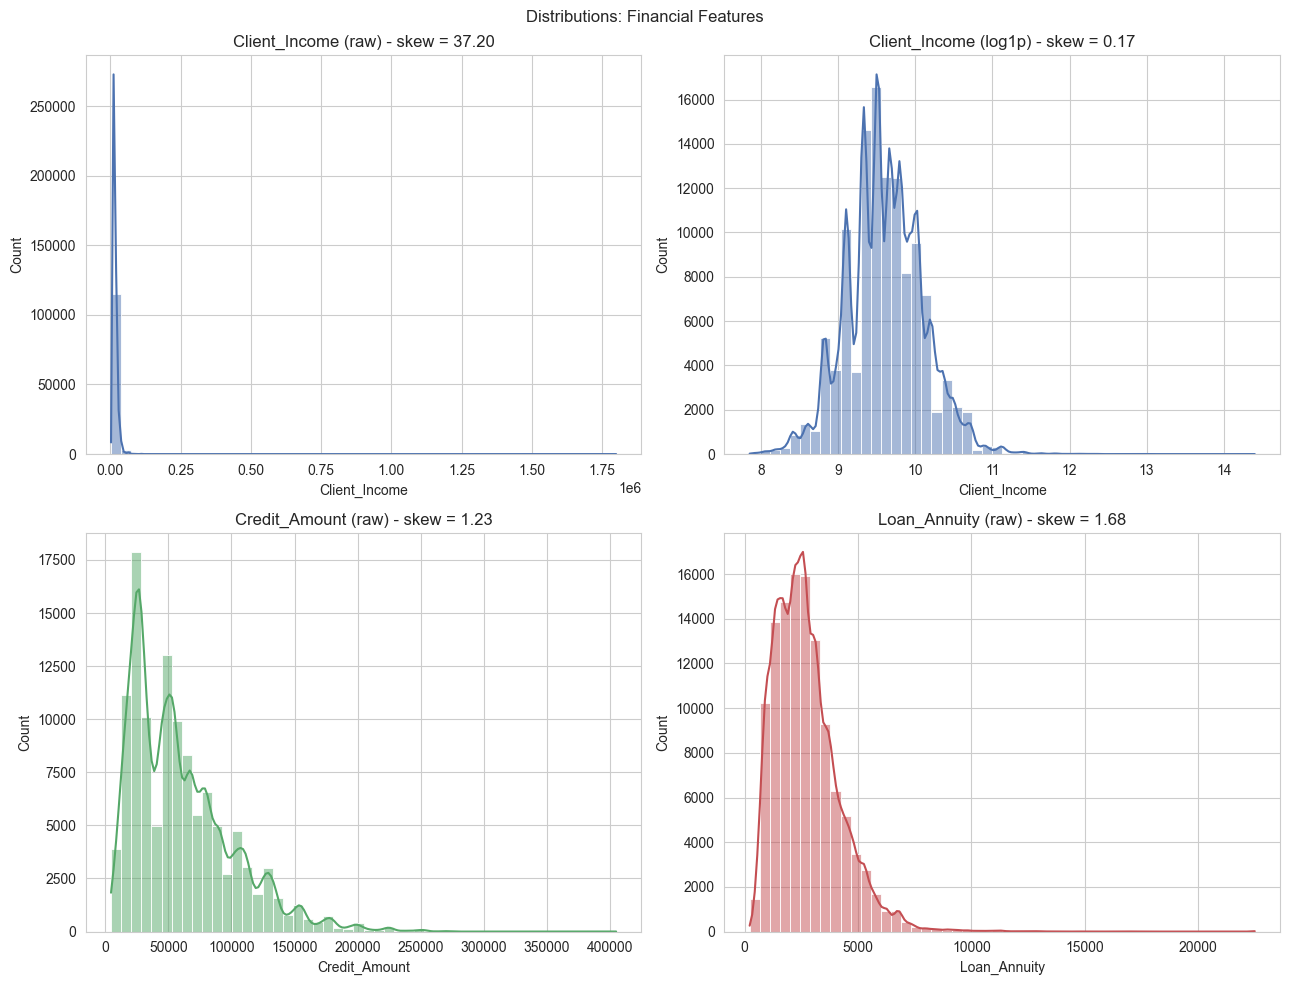

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.histplot(eda_df['Client_Income'].dropna(), bins=50, kde=True, ax=axes[0, 0], color='#4C72B0')
axes[0, 0].set_title(f"Client_Income (raw) - skew = {eda_df['Client_Income'].skew():.2f}")

sns.histplot(np.log1p(eda_df['Client_Income'].dropna()), bins=50, kde=True, ax=axes[0, 1], color='#4C72B0')
axes[0, 1].set_title(f"Client_Income (log1p) - skew = {np.log1p(eda_df['Client_Income'].dropna()).skew():.2f}")

sns.histplot(eda_df['Credit_Amount'].dropna(), bins=50, kde=True, ax=axes[1, 0], color='#55A868')
axes[1, 0].set_title(f"Credit_Amount (raw) - skew = {eda_df['Credit_Amount'].skew():.2f}")

sns.histplot(eda_df['Loan_Annuity'].dropna(), bins=50, kde=True, ax=axes[1, 1], color='#C44E52')
axes[1, 1].set_title(f"Loan_Annuity (raw) - skew = {eda_df['Loan_Annuity'].skew():.2f}")

fig.suptitle('Distributions: Financial Features')
plt.tight_layout()

fig_dir = 'experiments/figures' if os.path.exists('experiments/figures') else '../experiments/figures'
plt.savefig(os.path.join(fig_dir, '06_financial_features_distributions.png'), dpi=150)
plt.show()

**Interpretation:** `Client_Income`'s raw skew of ~37 collapses to a much more symmetric, bell-shaped distribution after a log1p transform — a strong justification for log-transforming this feature in preprocessing if a scale-sensitive model (e.g. Logistic Regression) is used. `Credit_Amount` and `Loan_Annuity` are moderately right-skewed (skew 1.2-1.7) with a visible long tail but no extreme single-outlier distortion — a milder log-transform is optional rather than essential for these two.


### 6.2 Numeric Features: Age and Credit Bureau Scores

`Age_Days` is converted to years for readability (dividing by 365) purely for this plot.


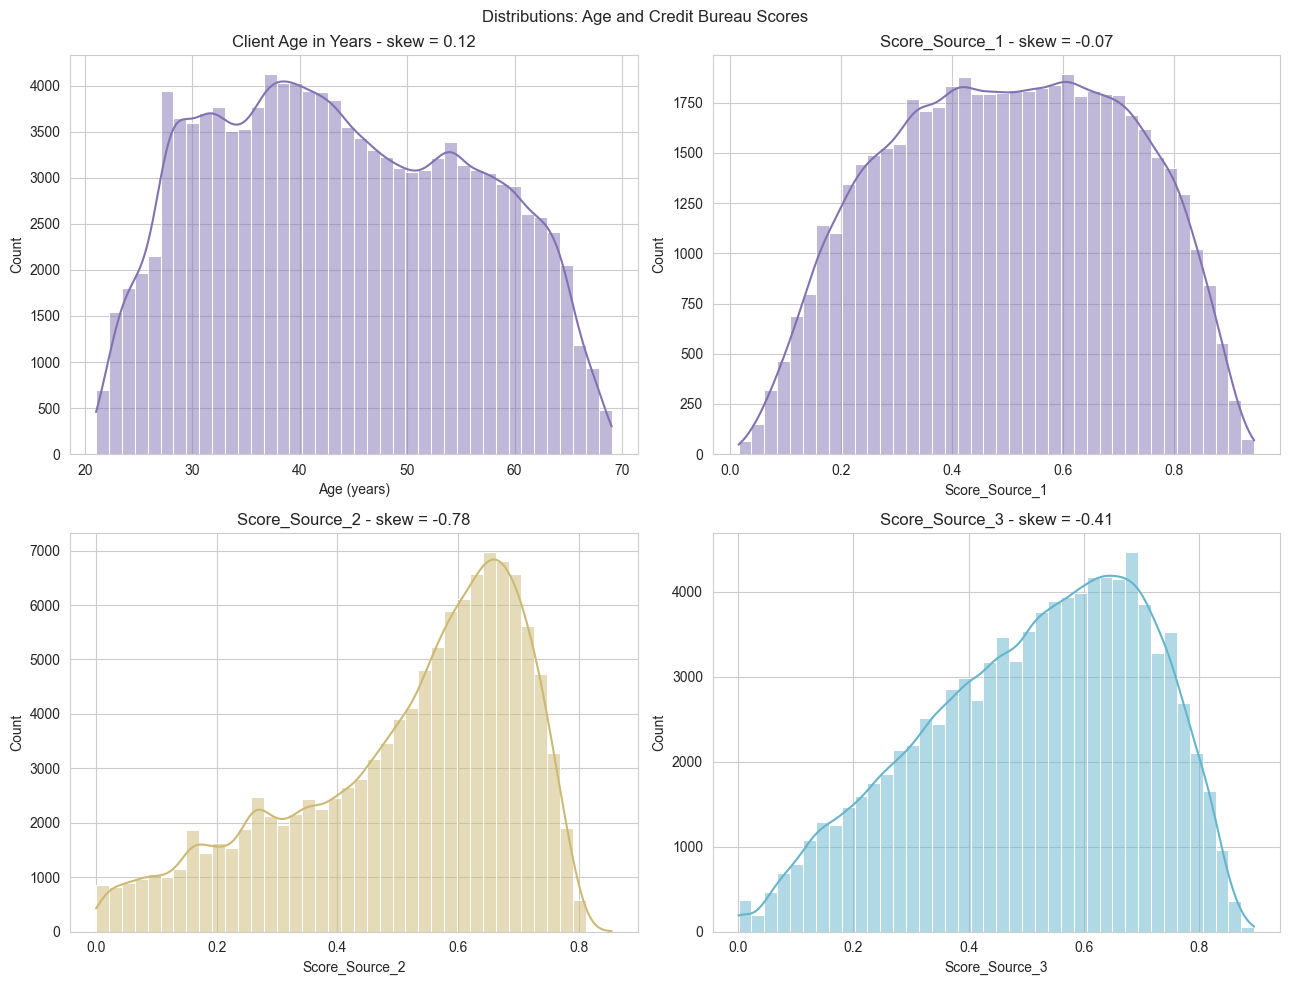

In [20]:
age_years = eda_df['Age_Days'] / 365

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.histplot(age_years.dropna(), bins=40, kde=True, ax=axes[0, 0], color='#8172B2')
axes[0, 0].set_title(f"Client Age in Years - skew = {age_years.skew():.2f}")
axes[0, 0].set_xlabel('Age (years)')

sns.histplot(eda_df['Score_Source_1'].dropna(), bins=40, kde=True, ax=axes[0, 1], color='#8172B2')
axes[0, 1].set_title(f"Score_Source_1 - skew = {eda_df['Score_Source_1'].skew():.2f}")

sns.histplot(eda_df['Score_Source_2'].dropna(), bins=40, kde=True, ax=axes[1, 0], color='#CCB974')
axes[1, 0].set_title(f"Score_Source_2 - skew = {eda_df['Score_Source_2'].skew():.2f}")

sns.histplot(eda_df['Score_Source_3'].dropna(), bins=40, kde=True, ax=axes[1, 1], color='#64B5CD')
axes[1, 1].set_title(f"Score_Source_3 - skew = {eda_df['Score_Source_3'].skew():.2f}")

fig.suptitle('Distributions: Age and Credit Bureau Scores')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, '06_age_and_scores_distributions.png'), dpi=150)
plt.show()

**Interpretation:** applicant age ranges realistically from 21-69 years with a roughly symmetric spread (skew ~0.12) - no cleaning needed. All three credit bureau scores are mildly-to-moderately left-skewed (more applicants scoring on the higher side), with `Score_Source_2` the most skewed (-0.78) - consistent with its shape already seen in Section 5's boxplot. None of the three need a transform; they're already well-behaved 0-1 scores.


### 6.3 Categorical Features

For each column, missing values are shown as their own `"Missing"` bar so the scale of missingness (already quantified in `01_data_understanding.ipynb`) is visible alongside the real categories.


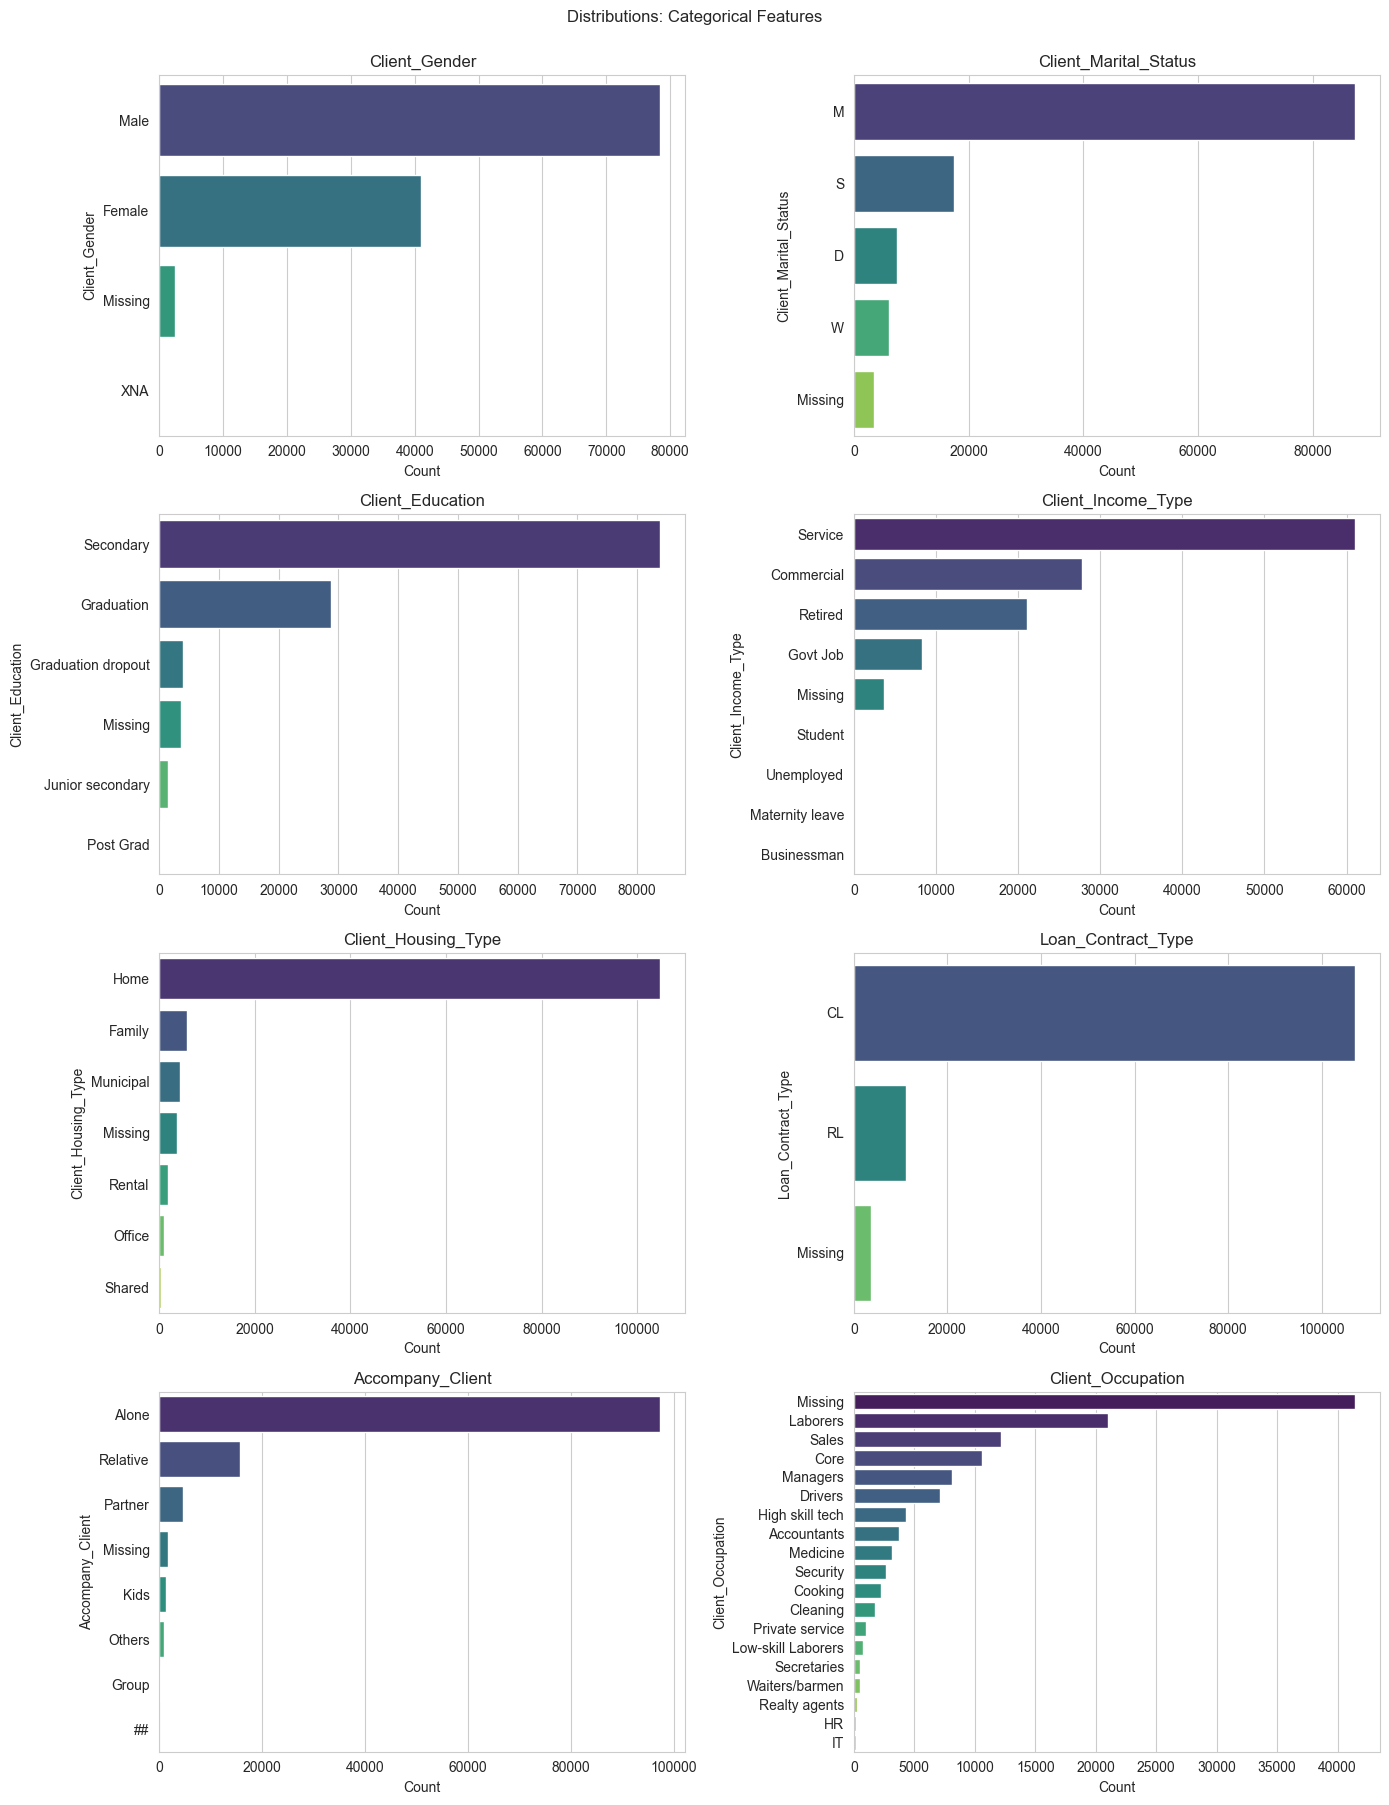

In [21]:
cat_cols_to_plot = [
    'Client_Gender', 'Client_Marital_Status', 'Client_Education', 'Client_Income_Type',
    'Client_Housing_Type', 'Loan_Contract_Type', 'Accompany_Client', 'Client_Occupation'
]

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols_to_plot):
    counts = eda_df[col].fillna('Missing').value_counts()
    sns.barplot(x=counts.values, y=counts.index, ax=axes[i], hue=counts.index, palette='viridis', legend=False)
    axes[i].set_title(col)
    axes[i].set_xlabel('Count')

fig.suptitle('Distributions: Categorical Features', y=1.0)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, '06_categorical_features_distributions.png'), dpi=150)
plt.show()

**Interpretation:**
- `Client_Gender`: Male applicants (78,463) outnumber Female (40,977) roughly 2:1.
- `Client_Marital_Status`: dominated by married (`M`, 87,349); single/divorced/widowed each much smaller.
- `Client_Education`: `Secondary` dominates (83,911); higher education categories (`Graduation`, `Post Grad`) are comparatively rare.
- `Client_Income_Type`: `Service` is the largest group (61,028), followed by `Commercial` and `Retired` — consistent with the retirement population identified in Section 3.
- `Client_Housing_Type`: the vast majority (`104,870`) live in `Home` housing; other categories are small by comparison.
- `Loan_Contract_Type`: heavily dominated by `CL` (107,118) over `RL` (11,087).
- `Accompany_Client`: most applicants apply `Alone` (97,409).
- `Client_Occupation`: `Missing` is actually the single largest bar (41,435) — larger than any real occupation category. This lines up with the retired/unemployed population from Section 3 (no current occupation), rather than being a random data-quality gap.


Looking closely at the `Accompany_Client` panel above, two categories stand out that weren't caught by Section 4's fixed-token placeholder scan: `"Group"` (a legitimate, just-rare category) and `"##"` (which looks like another disguised placeholder, similar in spirit to the `"XNA"` cases from Section 4). We check it properly here rather than assuming.


In [22]:
accompany_counts = eda_df['Accompany_Client'].value_counts(dropna=False)
print(accompany_counts)
print()
is_hash_placeholder = eda_df['Accompany_Client'] == '##'
print(f"Rows with Accompany_Client == '##': {is_hash_placeholder.sum()}")
eda_df.loc[is_hash_placeholder, ['Accompany_Client', 'Client_Income_Type', 'Default']]

Accompany_Client
Alone       97409
Relative    15748
Partner      4516
NaN          1746
Kids         1334
Others        987
Group         104
##             12
Name: count, dtype: int64

Rows with Accompany_Client == '##': 12


,Accompany_Client,Client_Income_Type,Default
3758,##,Commercial,0
32663,##,Service,0
36703,##,Service,1
37811,##,Service,0
39747,##,Retired,0
53102,##,Retired,0
58513,##,Commercial,1
61760,##,NaN,0
62524,##,Service,0
72933,##,Commercial,0


**Interpretation:** `"##"` appears in just **12 rows**, spread across different `Client_Income_Type` values (`Commercial`, `Service`, `Retired`) rather than concentrated in one group. Unlike `Type_Organization`'s `"XNA"`, this is **not** tied to the retirement pattern — it looks like an isolated data-entry issue, the same kind as the 3 `Client_Gender == "XNA"` rows from Section 4.

**Decision:** treat `Accompany_Client == "##"` as missing data in `03_data_preprocessing.ipynb`, the same way the `Client_Gender` placeholder will be handled.

**Lesson for this notebook's own process:** a fixed placeholder token list (Section 4) will only catch what we already thought to search for. Visualising the actual category counts here caught something the manual list missed — a good reminder to treat automated checks and visual inspection as complementary, not either/or.


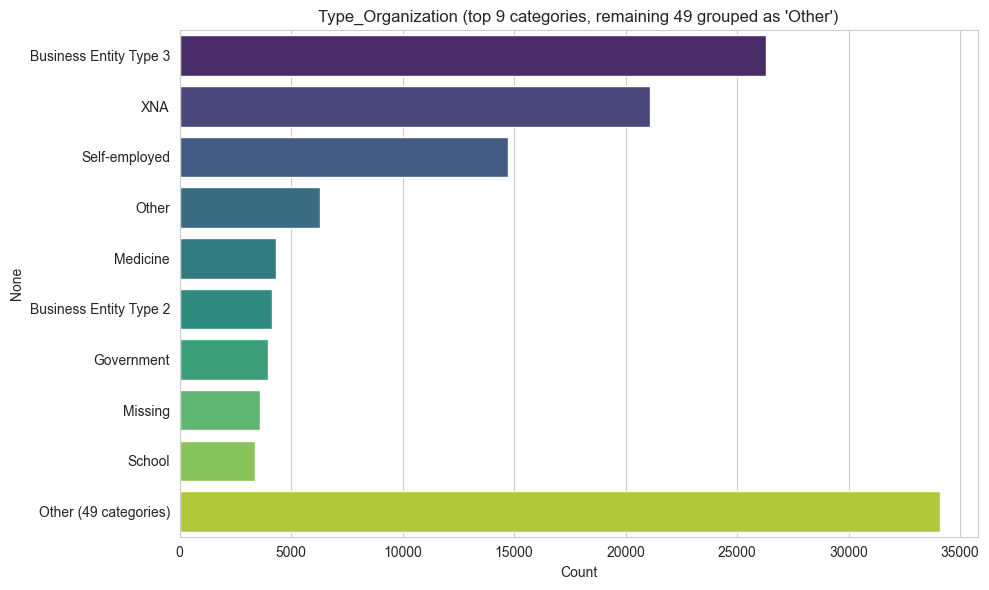

In [23]:
# Type_Organization has 58 unique categories - group the smaller ones into "Other" purely for readability
top_n = 9
org_counts = eda_df['Type_Organization'].fillna('Missing').value_counts()
top_orgs = org_counts.head(top_n)
other_count = org_counts.iloc[top_n:].sum()
org_counts_grouped = pd.concat([top_orgs, pd.Series({'Other (49 categories)': other_count})])

plt.figure(figsize=(10, 6))
sns.barplot(x=org_counts_grouped.values, y=org_counts_grouped.index, hue=org_counts_grouped.index, palette='viridis', legend=False)
plt.title(f"Type_Organization (top {top_n} categories, remaining 49 grouped as 'Other')")
plt.xlabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, '06_type_organization_distribution.png'), dpi=150)
plt.show()

**Interpretation:** `Business Entity Type 3` is the single largest real category (26,279), followed immediately by `"XNA"` (21,085 — the disguised missing/retirement marker confirmed in Section 4). The "Other" bucket of 49 remaining categories still adds up to a meaningful share, confirming this is a genuinely high-cardinality column. **Decision for `04_feature_engineering.ipynb`:** group the long tail of rare `Type_Organization` categories (e.g. those below a minimum frequency threshold) into an explicit `"Other"` category before encoding, to avoid an explosion of one-hot columns for categories with very few observations.


## 7. Target Variable Distribution: `Default`

`01_data_understanding.ipynb` already established the class split numerically (~91.9% non-default vs ~8.1% default). Before moving into how individual features relate to `Default` (Section 8), we visualise this imbalance directly, since it's the single most important fact shaping every modelling decision from here on.


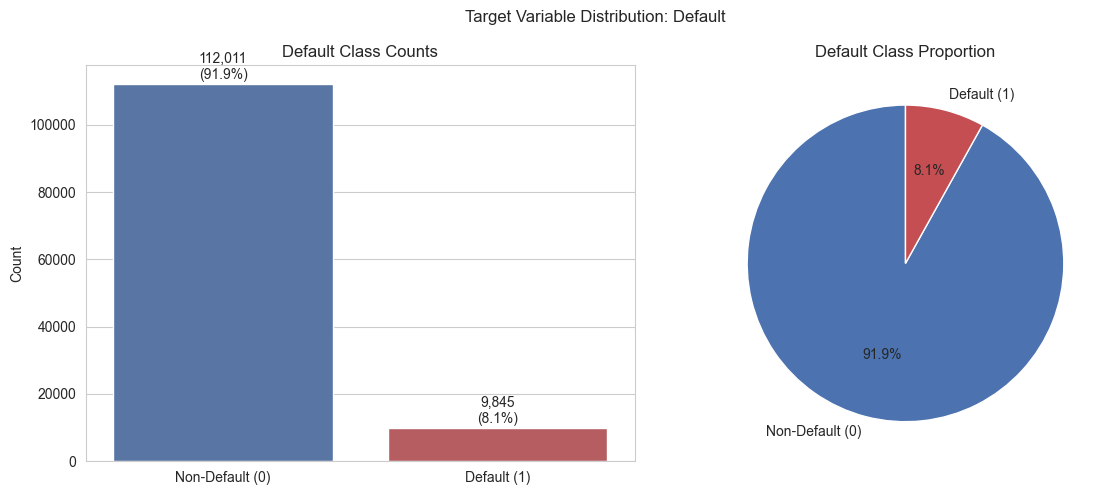

In [24]:
default_counts = eda_df['Default'].value_counts().sort_index()
default_pct = eda_df['Default'].value_counts(normalize=True).sort_index() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=['Non-Default (0)', 'Default (1)'], y=default_counts.values, hue=['Non-Default (0)', 'Default (1)'], palette=['#4C72B0', '#C44E52'], legend=False, ax=axes[0])
axes[0].set_title('Default Class Counts')
axes[0].set_ylabel('Count')
for i, (count, pct) in enumerate(zip(default_counts.values, default_pct.values)):
    axes[0].text(i, count + 1500, f"{count:,}\n({pct:.1f}%)", ha='center')

axes[1].pie(default_counts.values, labels=['Non-Default (0)', 'Default (1)'], autopct='%1.1f%%',
            colors=['#4C72B0', '#C44E52'], startangle=90)
axes[1].set_title('Default Class Proportion')

fig.suptitle('Target Variable Distribution: Default')
plt.tight_layout()

fig_dir = 'experiments/figures' if os.path.exists('experiments/figures') else '../experiments/figures'
plt.savefig(os.path.join(fig_dir, '07_target_distribution.png'), dpi=150)
plt.show()

**Interpretation:** the dataset is heavily imbalanced — non-defaulters outnumber defaulters roughly **11.4 to 1**. This has concrete consequences for the rest of the project:

- **Evaluation metrics:** accuracy alone would be misleading (a model predicting "no default" for every applicant would already score ~91.9% accuracy while being useless). Precision, recall, F1-score, and ROC-AUC/PR-AUC for the default class will be prioritised, as already planned in the dataset proposal.
- **Validation strategy:** train/test splitting must be **stratified** on `Default` so both splits preserve this ~92/8 ratio.
- **Modelling:** class weighting or resampling techniques (e.g. SMOTE) will be evaluated in `05_baseline_models.ipynb`/`07_hyperparameter_tuning.ipynb` to help models pay adequate attention to the minority (default) class.

This confirms — rather than changes — the plan already set out in the dataset proposal; no new decision is introduced here.


## 8. Bivariate Analysis: Features vs. `Default`

This is where we start finding out what actually relates to loan default. We compare numeric features by class (mean/median, boxplots) and compute the default rate per category for key categorical features.

Note: `Employed_Days`'s relationship with `Default` was already established in Section 3 (5.53% default rate for the retired/unemployed sentinel group vs 8.61% for everyone else), so it isn't repeated here.


### 8.1 Numeric Features vs. `Default`


In [25]:
numeric_cols_vs_target = [
    'Client_Income', 'Credit_Amount', 'Loan_Annuity', 'Age_Days',
    'Score_Source_1', 'Score_Source_2', 'Score_Source_3',
    'Social_Circle_Default', 'Credit_Bureau'
]

comparison_table = eda_df.groupby('Default')[numeric_cols_vs_target].agg(['mean', 'median']).T
comparison_table.columns = ['Non_Default (0)', 'Default (1)']
comparison_table

Non_Default (0)   Default (1)
Client_Income         mean       16938.840039  16028.370216
                      median     14850.000000  13500.000000
Credit_Amount         mean       60418.311999  55825.151191
                      median     51856.200000  49752.000000
Loan_Annuity          mean        2726.495303   2661.496148
                      median      2497.050000   2528.325000
Age_Days              mean       16123.316658  14936.549194
                      median     15848.000000  14381.500000
Score_Source_1        mean           0.509964      0.391354
                      median         0.515809      0.367457
Score_Source_2        mean           0.522334      0.413062
                      median         0.572570      0.443698
Score_Source_3        mean           0.521139      0.394377
                      median         0.546023      0.385915
Social_Circle_Default mean           0.118391      0.104546
                      median         0.090200      0.082500
Credit_Bureau         mean           1.880278      2.019451
                      median         1.000000      2.000000

**Interpretation (from the table above):**
- The three credit bureau scores show the clearest separation: defaulters score noticeably lower on all three (e.g. `Score_Source_3` mean 0.394 for defaulters vs 0.521 for non-defaulters). This is the strongest signal seen so far.
- `Age_Days`: defaulters are younger on average (mean ≈ 40.9 years vs ≈ 44.2 years for non-defaulters).
- `Credit_Bureau` (number of bureau enquiries): defaulters have *more* enquiries on average (2.02 vs 1.88) — more active credit-shopping coincides with higher risk.
- `Client_Income` and `Credit_Amount` are both slightly lower for defaulters, but the gap is much smaller than for the credit scores or age.
- `Loan_Annuity` and `Social_Circle_Default` show very little difference between classes — likely weak predictors on their own.

We visualise the more informative ones as boxplots below.


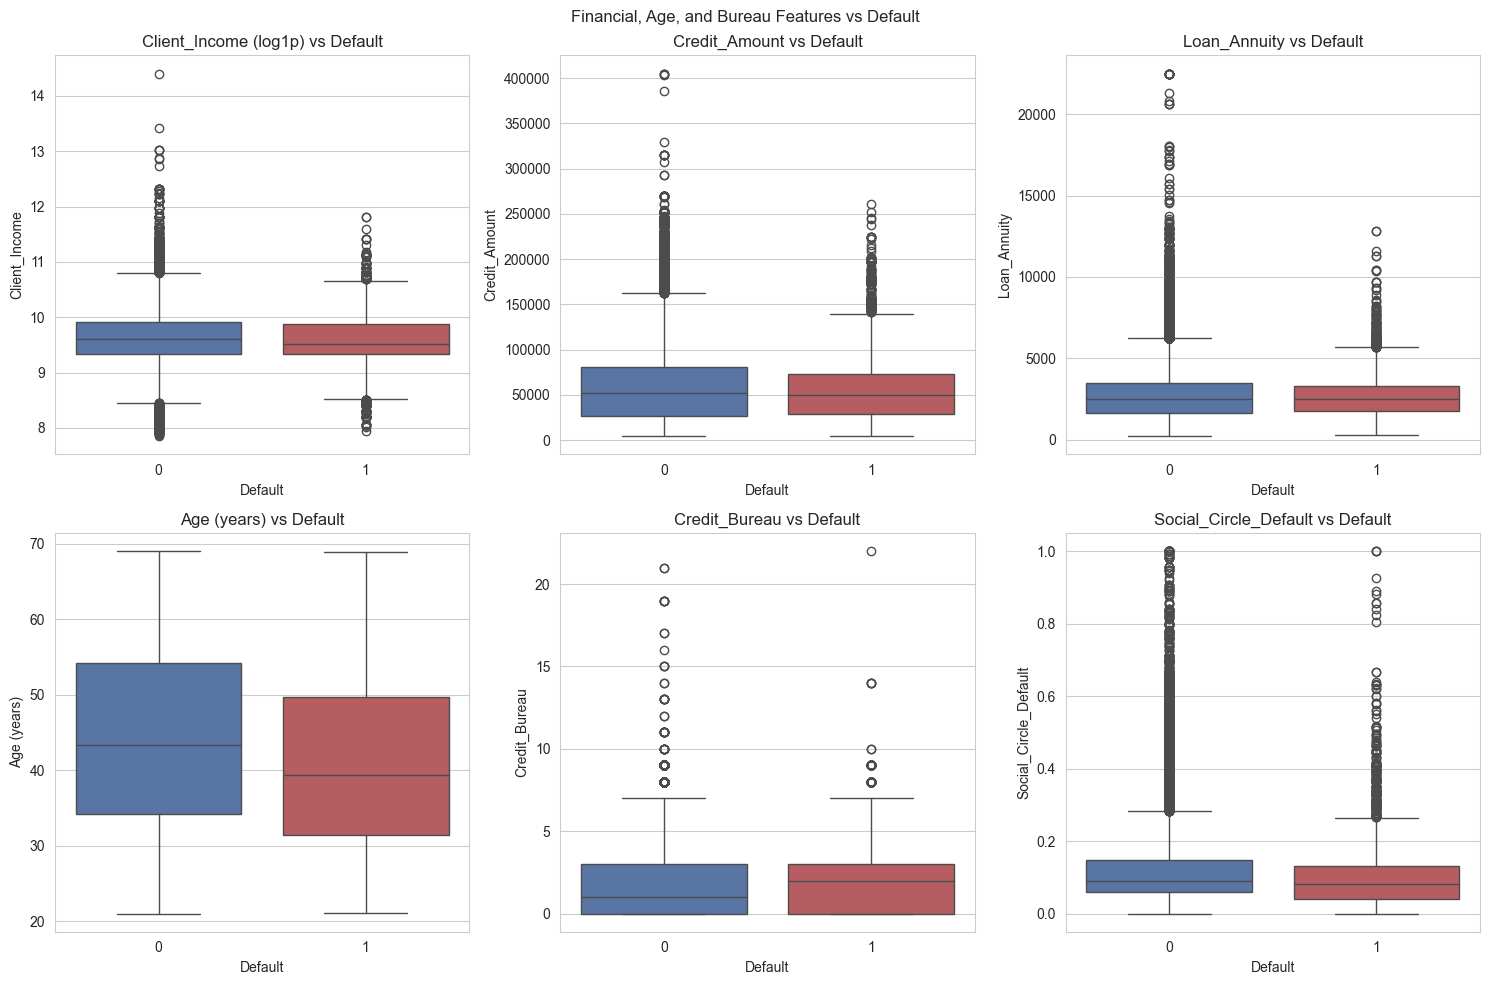

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

sns.boxplot(x='Default', y=np.log1p(eda_df['Client_Income']), data=eda_df, ax=axes[0, 0], hue='Default', palette=['#4C72B0', '#C44E52'], legend=False)
axes[0, 0].set_title('Client_Income (log1p) vs Default')

sns.boxplot(x='Default', y='Credit_Amount', data=eda_df, ax=axes[0, 1], hue='Default', palette=['#4C72B0', '#C44E52'], legend=False)
axes[0, 1].set_title('Credit_Amount vs Default')

sns.boxplot(x='Default', y='Loan_Annuity', data=eda_df, ax=axes[0, 2], hue='Default', palette=['#4C72B0', '#C44E52'], legend=False)
axes[0, 2].set_title('Loan_Annuity vs Default')

age_years_series = eda_df['Age_Days'] / 365
sns.boxplot(x=eda_df['Default'], y=age_years_series, ax=axes[1, 0], hue=eda_df['Default'], palette=['#4C72B0', '#C44E52'], legend=False)
axes[1, 0].set_title('Age (years) vs Default')
axes[1, 0].set_ylabel('Age (years)')

sns.boxplot(x='Default', y='Credit_Bureau', data=eda_df, ax=axes[1, 1], hue='Default', palette=['#4C72B0', '#C44E52'], legend=False)
axes[1, 1].set_title('Credit_Bureau vs Default')

sns.boxplot(x='Default', y='Social_Circle_Default', data=eda_df, ax=axes[1, 2], hue='Default', palette=['#4C72B0', '#C44E52'], legend=False)
axes[1, 2].set_title('Social_Circle_Default vs Default')

fig.suptitle('Financial, Age, and Bureau Features vs Default')
plt.tight_layout()

fig_dir = 'experiments/figures' if os.path.exists('experiments/figures') else '../experiments/figures'
plt.savefig(os.path.join(fig_dir, '08_numeric_features_vs_default.png'), dpi=150)
plt.show()

**Interpretation:** the boxplots confirm the table above — the median lines for `Age` and `Credit_Bureau` shift visibly between classes, while `Loan_Annuity` and `Social_Circle_Default` show heavily overlapping boxes with barely any shift, reinforcing that these two are weak standalone predictors.


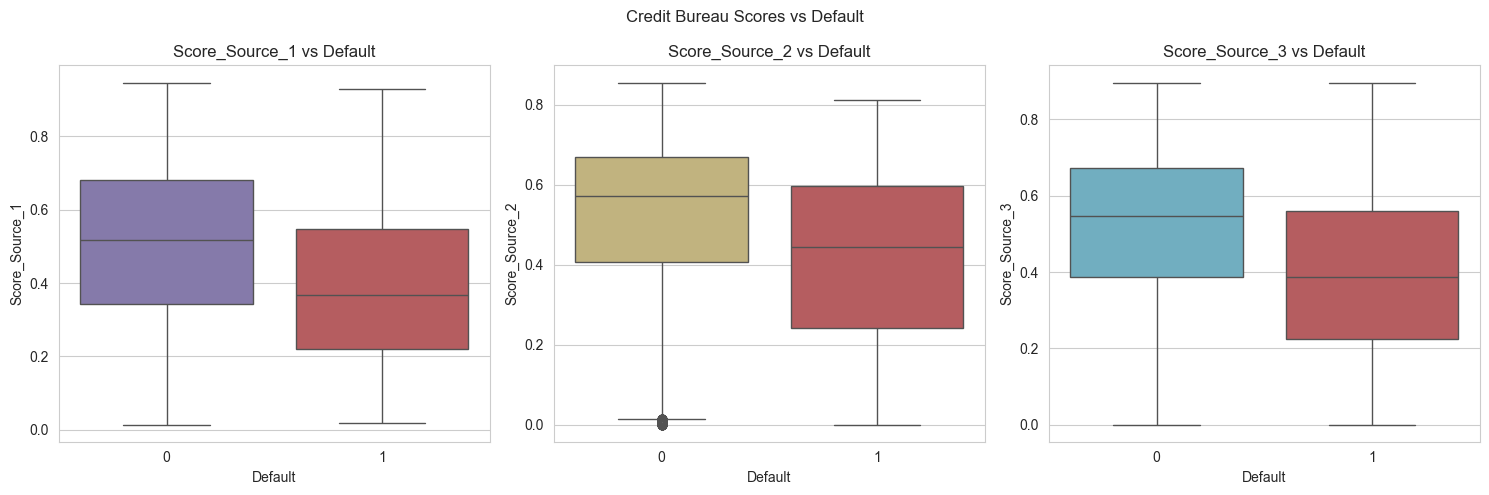

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, color in zip(axes, ['Score_Source_1', 'Score_Source_2', 'Score_Source_3'], ['#8172B2', '#CCB974', '#64B5CD']):
    sns.boxplot(x='Default', y=col, data=eda_df, ax=ax, hue='Default', palette=[color, '#C44E52'], legend=False)
    ax.set_title(f'{col} vs Default')

fig.suptitle('Credit Bureau Scores vs Default')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, '08_credit_scores_vs_default.png'), dpi=150)
plt.show()

**Interpretation:** all three credit scores show a clear, visible downward shift for defaulters — the most separated boxplots of any feature examined so far. This strongly suggests `Score_Source_1/2/3` will be among the most important predictive features for the final models, consistent with these being external credit-bureau risk scores.


### 8.2 Categorical Features vs. `Default`

For each category, we compute the default rate (% of applicants in that category who defaulted). **Sample size matters here** — a category with only a handful of applicants can show an extreme rate purely by chance, so counts are shown alongside every rate.


In [28]:
categorical_cols_vs_target = ['Client_Gender', 'Client_Education', 'Client_Marital_Status', 'Client_Income_Type', 'Client_Housing_Type']

default_rate_tables = {}
for col in categorical_cols_vs_target:
    g = eda_df.groupby(col)['Default'].agg(['mean', 'count'])
    g['mean'] = (g['mean'] * 100).round(2)
    g = g.sort_values('mean', ascending=False)
    default_rate_tables[col] = g
    print(f"--- {col} ---")
    print(g)
    print()

--- Client_Gender ---
                mean  count
Client_Gender              
Female         10.02  40977
Male            7.07  78463
XNA             0.00      3

--- Client_Education ---
                     mean  count
Client_Education                
Junior secondary    10.52   1455
Secondary            9.09  83911
Graduation dropout   8.28   3960
Graduation           5.08  28819
Post Grad            1.52     66

--- Client_Marital_Status ---
                       mean  count
Client_Marital_Status             
S                      9.70  17404
M                      7.91  87349
D                      7.73   7556
W                      6.45   6074

--- Client_Income_Type ---
                     mean  count
Client_Income_Type              
Unemployed          50.00      6
Service              9.48  61028
Commercial           7.59  27764
Govt Job             5.83   8303
Retired              5.54  21043
Businessman          0.00      1
Maternity leave      0.00      2
Student        

**Interpretation of the tables above:**
- `Client_Gender`: Female applicants default more often (10.02%) than Male (7.07%). (`XNA`'s 0% is meaningless — only 3 rows.)
- `Client_Education`: a clear, monotonic pattern for the well-populated categories — `Secondary` (9.09%, n=83,911) defaults more than `Graduation` (5.08%, n=28,819). `Post Grad`'s 1.52% and `Junior secondary`'s 10.52% are based on much smaller samples (66 and 1,455 rows) and should be trusted less.
- `Client_Marital_Status`: `Single` applicants default most (9.70%), `Widowed` least (6.45%) — all four categories have reasonably large samples (6,000+), so this pattern looks trustworthy.
- `Client_Income_Type`: excluding tiny categories (`Unemployed` n=6, `Businessman` n=1, `Student` n=8 — not statistically meaningful), the reliable pattern is `Service` (9.48%) > `Commercial` (7.59%) > `Govt Job` (5.83%) > `Retired` (5.54%) — consistent with the lower-risk retiree pattern already found in Section 3.
- `Client_Housing_Type`: `Rental` (12.61%) and `Family` (11.24%) housing show higher default rates than `Home` (7.79%, the largest group by far) or `Office` (6.79%).

**Decision:** these five categorical features all show plausible, explainable relationships with `Default` in their well-populated categories, making them good candidates to keep through feature selection. Categories with very small sample sizes (e.g. `Unemployed`, `Businessman`, `Post Grad`) should not be over-interpreted, and may benefit from grouping into a broader category during feature engineering to avoid the model overfitting to statistical noise.


## 9. Multicollinearity: Relationships Between Features

Section 8 looked at each feature's relationship *with the target*. Here we look at relationships *between features themselves* — redundant, highly-correlated features can distort scale-sensitive models (e.g. Logistic Regression coefficients become unstable) and inflate the apparent importance of a variable that's really just a proxy for another one. This directly feeds into feature selection in `04_feature_engineering.ipynb`.


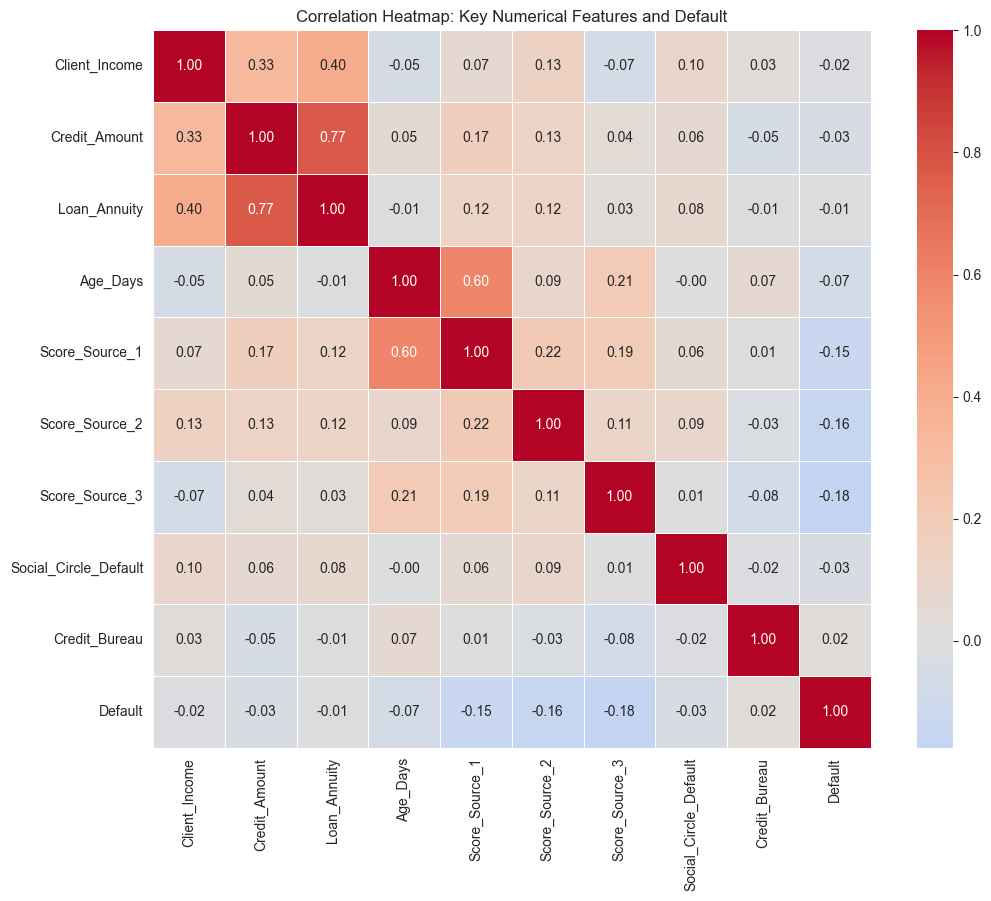

In [29]:
corr_cols = [
    'Client_Income', 'Credit_Amount', 'Loan_Annuity', 'Age_Days',
    'Score_Source_1', 'Score_Source_2', 'Score_Source_3',
    'Social_Circle_Default', 'Credit_Bureau', 'Default'
]

correlation_matrix = eda_df[corr_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap: Key Numerical Features and Default')
plt.tight_layout()

fig_dir = 'experiments/figures' if os.path.exists('experiments/figures') else '../experiments/figures'
plt.savefig(os.path.join(fig_dir, '09_correlation_heatmap.png'), dpi=150)
plt.show()

**Interpretation:**
- **`Credit_Amount` and `Loan_Annuity` are strongly correlated (r = 0.77)** — this makes intuitive sense, since a bigger loan naturally comes with a bigger repayment instalment. This is the one pair here worth treating as partially redundant.
- **`Age_Days` and `Score_Source_1` show a moderate correlation (r = 0.60)** — worth noting, but not extreme enough to call redundant on its own.
- **`Client_Income` correlates moderately with `Loan_Annuity` (0.40) and `Credit_Amount` (0.33)** — expected, since loan sizing is naturally informed by income.
- Every feature's correlation with `Default` itself is weak in isolation (all `|r| < 0.2`) — consistent with Section 8's finding that no single numeric feature separates the classes cleanly on its own; the credit scores were the closest, and even those only reached ~-0.15 to -0.18 in linear correlation despite showing a clear separation in the boxplots. This is a reminder that **correlation only measures linear relationships** — the boxplots in Section 8 are still the more informative view here.


In [30]:
# The three credit bureau scores are all described as "credit risk scores" - are they measuring
# the same thing, or genuinely different information? Zoom in on just these three.
score_corr = eda_df[['Score_Source_1', 'Score_Source_2', 'Score_Source_3']].corr()
score_corr

,Score_Source_1,Score_Source_2,Score_Source_3
Score_Source_1,1.000000,0.218825,0.188195
Score_Source_2,0.218825,1.000000,0.110555
Score_Source_3,0.188195,0.110555,1.000000


**Interpretation:** despite all three being external credit bureau scores, they are only weakly correlated with **each other** (r = 0.11-0.22) — much weaker than the `Credit_Amount`/`Loan_Annuity` pair. This means each score is capturing genuinely different information (likely from different bureaus/methodologies) rather than being three copies of the same signal. Combined with Section 8's finding that all three separate the `Default` classes well, **all three should be kept as separate features** rather than merged or reduced.

### Summary of Section 9 decisions
1. `Credit_Amount` and `Loan_Annuity` (r = 0.77): flag as the main multicollinearity concern. For scale-sensitive models (Logistic Regression), consider dropping one or engineering a combined feature (e.g. `Credit_Amount / Loan_Annuity` as an implied loan term) in `04_feature_engineering.ipynb`. Tree-based models (Random Forest, XGBoost) are not meaningfully affected by this and can keep both.
2. `Score_Source_1/2/3`: keep all three — low mutual correlation confirms they are not redundant.
3. No other feature pair shows correlation strong enough to warrant action.


## 10. Data Leakage Re-verification

The dataset proposal (Section 9.1) stated that no column appeared to directly reveal the loan's actual repayment outcome, but promised this would be **re-verified during EDA**. Having now examined every candidate feature individually (Section 6), against the target (Section 8), and against each other (Section 9), we do that re-verification properly here: every one of the 38 candidate feature columns is checked against the rule that it must represent information available **at or before the moment of application** — nothing that could only be known after the loan was disbursed and repayment began.


In [31]:
# Group every candidate feature (excludes ID and Default) by category, with a leakage justification for each.
feature_leakage_check = {
    'Applicant demographics': {
        'Client_Gender': 'Applicant attribute, known at application.',
        'Client_Marital_Status': 'Applicant attribute, known at application.',
        'Client_Education': 'Applicant attribute, known at application.',
        'Child_Count': 'Applicant attribute, known at application.',
        'Client_Family_Members': 'Applicant attribute, known at application.',
        'Age_Days': 'Derived from date of birth, known at application.',
        'Population_Region_Relative': 'Region-level statistic tied to where the applicant lives, known at application.',
        'Cleint_City_Rating': 'City-level rating, known at application.',
    },
    'Financial details': {
        'Client_Income': 'Declared/verified at application.',
        'Credit_Amount': 'The amount being requested - set at application.',
        'Loan_Annuity': 'Instalment size calculated from the requested loan terms at application.',
    },
    'Asset ownership': {
        'Car_Owned': 'Applicant attribute, known at application.',
        'Bike_Owned': 'Applicant attribute, known at application.',
        'House_Own': 'Applicant attribute, known at application.',
        'Own_House_Age': 'Property attribute, known at application (if owned).',
    },
    'Employment information': {
        'Client_Income_Type': 'Applicant attribute, known at application.',
        'Client_Occupation': 'Applicant attribute, known at application.',
        'Type_Organization': 'Applicant attribute, known at application.',
        'Employed_Days': 'Employment history up to the application date - not a future outcome.',
    },
    'Application / contact details': {
        'Loan_Contract_Type': 'Set as part of the application itself.',
        'Client_Housing_Type': 'Applicant attribute, known at application.',
        'Accompany_Client': 'Recorded at the moment of application submission.',
        'Application_Process_Day': 'Recorded at the moment of application submission.',
        'Application_Process_Hour': 'Recorded at the moment of application submission.',
        'Registration_Days': 'Days since ID/registration document was issued - a pre-application fact.',
        'ID_Days': 'Days since ID document was issued - a pre-application fact.',
        'Mobile_Tag': 'Contact-detail flag, known at application.',
        'Homephone_Tag': 'Contact-detail flag, known at application.',
        'Workphone_Working': 'Contact-detail flag, known at application.',
        'Client_Permanent_Match_Tag': 'Address-verification flag, known at application.',
        'Client_Contact_Work_Tag': 'Contact-verification flag, known at application.',
        'Phone_Change': 'Days since phone number last changed - a pre-application fact.',
        'Active_Loan': "Whether the applicant already holds another active loan - a pre-application credit-bureau fact, not this loan's outcome.",
    },
    'Credit bureau information': {
        'Score_Source_1': 'External bureau score computed from historical credit data prior to this application.',
        'Score_Source_2': 'External bureau score computed from historical credit data prior to this application.',
        'Score_Source_3': 'External bureau score computed from historical credit data prior to this application.',
        'Social_Circle_Default': "Default history observed in the applicant's social circle (other people), not this applicant's own future repayment outcome.",
        'Credit_Bureau': 'Count of prior bureau enquiries up to the application date.',
    },
}

# Completeness check: every candidate feature column must appear exactly once
all_columns = set(df.columns) - {'ID', 'Default'}
checked_columns = set()
for group in feature_leakage_check.values():
    checked_columns.update(group.keys())

missing = all_columns - checked_columns
extra = checked_columns - all_columns

print(f"Total candidate feature columns: {len(all_columns)}")
print(f"Columns checked above: {len(checked_columns)}")
print(f"Missing from the check (BAD if non-empty): {missing}")
print(f"Extra / misspelled entries (BAD if non-empty): {extra}")

Total candidate feature columns: 38
Columns checked above: 38
Missing from the check (BAD if non-empty): set()
Extra / misspelled entries (BAD if non-empty): set()


**Interpretation:** the completeness check confirms all 38 candidate feature columns were reviewed and none were missed or misspelled. Grouped by category, every single one represents information genuinely available **at or before** the moment of application:
- Demographics, financial details, asset ownership, and employment information are all applicant-supplied or pre-existing attributes.
- Application/contact details are recorded at the moment of submission itself.
- Credit bureau information (`Score_Source_1/2/3`, `Credit_Bureau`) reflects the applicant's history *prior to* this application, not its outcome.
- `Social_Circle_Default` was double-checked specifically because its name sounds outcome-related — but it describes default behaviour observed in the applicant's *social circle* (other people), not the applicant's own future repayment on *this* loan, so it is not leakage.

**Corroborating evidence from earlier sections:** if any of these columns leaked the outcome, we would expect to see it correlate almost perfectly with `Default`. Section 9's correlation heatmap showed the *strongest* correlation with `Default` across all numeric features was only `Score_Source_3` at `r = -0.18` — nowhere near the near-1.0 correlation a genuine leakage column would produce. This is consistent with there being no leakage.

**Decision:** no feature will be excluded for leakage reasons. The only column dropped from modelling will remain `ID` (Section 8, `01_data_understanding.ipynb`), which is excluded as a non-predictive identifier, not for leakage reasons.


## 11. Summary of EDA Findings and Handoff to Preprocessing

This section consolidates every finding and decision made across Sections 1-10 into a single reference for `03_data_preprocessing.ipynb` and `04_feature_engineering.ipynb`.

### 11.1 Data Quality Issues and Their Handling

| Issue | Found In | Scope | Decision |
|---|---|---|---|
| Numeric columns stored as text (`$`, `x`, `&`, `#VALUE!`, `@`, `#`) | `01_data_understanding.ipynb`, confirmed in Section 1 | 9 columns, a handful of rows each | Convert to numeric with `pd.to_numeric(errors='coerce')`; invalid entries become missing |
| `Employed_Days` sentinel (`365243`) | Section 3 | 21,098 rows (17.31%) | Split into (a) binary `Is_Retired_Or_Unemployed` flag, (b) numeric `Employed_Days` with sentinel rows set to missing |
| `Client_Gender == "XNA"` | Section 4 | 3 rows | Treat as missing |
| `Type_Organization == "XNA"` | Section 4 | 21,085 rows (17.30%), confirmed to overlap with the `Employed_Days` sentinel population | Keep as its own valid category (do **not** impute away) |
| `Accompany_Client == "##"` | Section 6 (visual discovery, missed by Section 4's token scan) | 12 rows | Treat as missing |
| `Score_Source_2 > 1` | Sections 2 and 5 | 6 rows (exact value 100.0) | Treat as missing |
| `Population_Region_Relative > 1` | Sections 2 and 5 | 2 rows (exact value 100.0) | Treat as missing |
| Remaining missing values (33 of 40 columns, per `01_data_understanding.ipynb`) | `01_data_understanding.ipynb` | Varies by column, up to ~66% (`Own_House_Age`) | Per-column strategy (impute / missing-indicator flag / drop) to be justified individually in `03_data_preprocessing.ipynb` based on missing rate and cause |

### 11.2 Outliers and Skewed Distributions

- **`Client_Income`**: extreme skew (raw skew ≈ 37.2, driven by a single ~1.8M-value outlier). Log-transform (`log1p`) reduces skew to ≈ 0.17 — strongly recommended for scale-sensitive models (e.g. Logistic Regression).
- **`Credit_Amount`** (skew ≈ 1.23) and **`Loan_Annuity`** (skew ≈ 1.68): moderately right-skewed with genuine high-value applicants, not errors. Log-transform is optional rather than essential.
- **`Social_Circle_Default`** and **`Credit_Bureau`**: sparse, mostly-zero, count-like variables with a long right tail — the IQR-flagged "outliers" (6.93% and 1.26% respectively) are expected for this shape and need no special treatment beyond standard missing-value handling.
- **`Age_Days`**, **`Score_Source_1`**, **`Score_Source_3`**: well-behaved, no outliers, no transform needed.

### 11.3 Feature Engineering Candidates (for `04_feature_engineering.ipynb`)

1. `Is_Retired_Or_Unemployed` binary flag, derived from the `Employed_Days` sentinel (Section 3).
2. Applicant age in years, derived from `Age_Days` (used for readability throughout this notebook; consider adding as an explicit feature).
3. Group rare `Type_Organization` categories (49 of 58 categories fall outside the top 9, Section 6) into an explicit `"Other"` bucket before encoding.
4. Consider a combined feature from `Credit_Amount` and `Loan_Annuity` (e.g. implied loan term = `Credit_Amount / Loan_Annuity`) given their strong correlation (Section 9, r = 0.77), particularly if a linear model is used.
5. Group small-sample categories across `Client_Education`, `Client_Income_Type`, and similar columns (e.g. `Post Grad` n=66, `Unemployed` n=6) to avoid the model overfitting to statistical noise (Section 8).

### 11.4 Class Imbalance

- `Default` is imbalanced: 112,011 non-default (91.9%) vs 9,845 default (8.1%) — a ratio of ≈ 11.4:1 (Section 7).
- **Validation strategy:** stratified train/test split to preserve this ratio in both sets.
- **Evaluation metrics:** prioritise precision, recall, F1-score, and ROC-AUC/PR-AUC for the default class over raw accuracy.
- **Modelling:** evaluate class weighting and/or resampling (e.g. SMOTE) in `05_baseline_models.ipynb` / `07_hyperparameter_tuning.ipynb`.

### 11.5 Most Informative Features Found So Far

- **Strongest individual signal:** `Score_Source_1/2/3` (external credit bureau scores) — all three show a clear, visible separation between defaulters and non-defaulters (Section 8), and are only weakly correlated with each other (Section 9), so all three should be kept.
- **Other meaningful signals:** applicant age (defaulters younger), `Credit_Bureau` enquiry count (defaulters have more), and several categorical features in their well-populated categories (`Client_Education`, `Client_Income_Type`, `Client_Housing_Type`, `Client_Marital_Status`, `Client_Gender`).
- **Weak standalone signals:** `Loan_Annuity`, `Social_Circle_Default` — retained for now, but not expected to be highly ranked in feature importance.

### 11.6 Multicollinearity

- `Credit_Amount` and `Loan_Annuity` are the one strongly correlated pair (r = 0.77) — flagged for possible redundancy handling in linear models (Section 9).
- No other feature pair shows concerning correlation.

### 11.7 Data Leakage

- All 38 candidate feature columns were reviewed and confirmed to represent information available at or before the moment of application (Section 10).
- No feature is excluded for leakage; `ID` remains the only excluded column, dropped as a non-predictive identifier.

### 11.8 Next Steps

`03_data_preprocessing.ipynb` will implement, on the training split only (to avoid leakage):
1. Numeric type correction and missing-value handling for the columns identified in Section 11.1.
2. The `Employed_Days` sentinel split and other placeholder-to-missing conversions.
3. Outlier treatment (log-transform) for `Client_Income`.
4. Categorical encoding, informed by the category groupings identified in Section 11.3.
5. Feature scaling, where required by the models selected.
6. A stratified train/test split.

`04_feature_engineering.ipynb` will then implement the derived features listed in Section 11.3 and perform feature selection informed by Sections 8 and 9.
